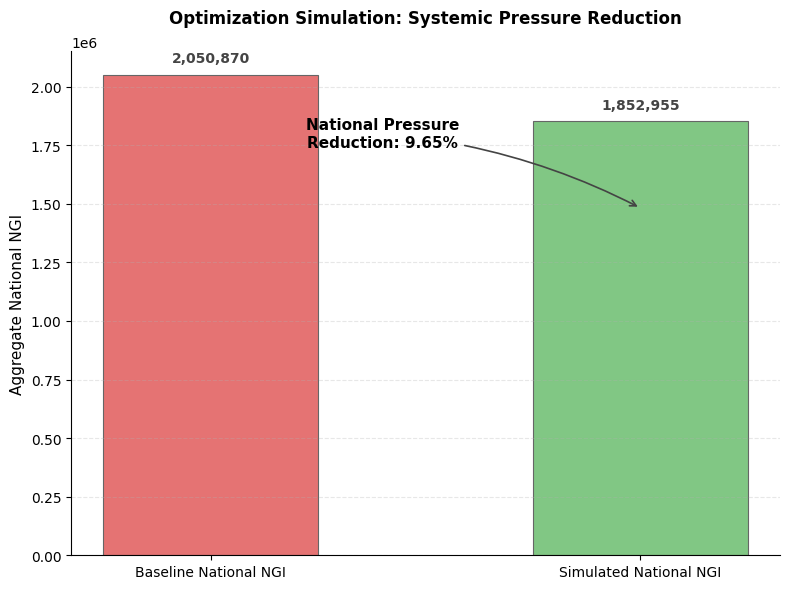

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. LOAD DATA
df = pd.read_csv('Phase4_Final_Policy_Results.csv')

# 2. SIMULATION LOGIC
REDUCTION_FACTOR = 0.25
red_mask = df['Policy_Category'] == 'Red: Critical Exclusion'
red_districts = df[red_mask].copy()
red_districts['Simulated_NGI'] = red_districts['General_NGI'] * (1 - REDUCTION_FACTOR)

# 3. IMPACT CALCULATION
total_baseline_ngi = df['General_NGI'].sum()
total_simulated_ngi = (df[~red_mask]['General_NGI'].sum() + red_districts['Simulated_NGI'].sum())
national_reduction_pct = ((total_baseline_ngi - total_simulated_ngi) / total_baseline_ngi) * 100

# 4. INTERMEDIATE SOFT PALETTE
# #E57373 is a Soft Coral (Light Red, but professional)
# #81C784 is a Pale Meadow Green (Light Green, but calm)
SOFT_INTERMEDIATE = ['#E57373', '#81C784']

plt.figure(figsize=(8, 6))

labels = ['Baseline National NGI', 'Simulated National NGI']
values = [total_baseline_ngi, total_simulated_ngi]

# Drawing bars with a slightly lighter edge for a modern academic look
bars = plt.bar(labels, values, color=SOFT_INTERMEDIATE, width=0.5, edgecolor='#666666', linewidth=0.8)

# --- CLEAN LAYOUT ---
plt.title('Optimization Simulation: Systemic Pressure Reduction', fontsize=12, fontweight='bold', pad=20)
plt.ylabel('Aggregate National NGI', fontsize=11)

# Style adjustments to make it look "light"
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Data labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + (total_baseline_ngi * 0.02),
             f'{height:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#444444')

# Reduction arrow and text
plt.annotate(f'National Pressure\nReduction: {national_reduction_pct:.2f}%',
             xy=(1, total_simulated_ngi * 0.8), xytext=(0.4, total_baseline_ngi * 0.85),
             arrowprops=dict(arrowstyle="->", color="#444444", lw=1.2, connectionstyle="arc3,rad=-0.1"),
             ha='center', fontsize=11, fontweight='bold', color='black') # A darker shade of the light green for text

plt.tight_layout()
plt.savefig('Phase4_Simulation_Impact_Soft_Intermediate.png', dpi=300)
plt.show()